# 합성 지진파 P파·S파·Noise 분류

이 노트북은 외부 데이터를 다운로드하지 않습니다. 함께 제공된 200개 합성 3성분 파형 CSV를 읽어 1D CNN으로 `P`, `S`, `noise`를 분류합니다.

> 주의: 합성 데이터는 학습 구조를 익히기 위한 교육용이며 실제 관측자료의 성능을 보장하지 않습니다.

In [ ]:
# 필요한 패키지가 없다면 이 셀의 주석을 해제하세요. (데이터 다운로드는 하지 않음)
# %pip install numpy pandas matplotlib scikit-learn torch

In [1]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
print('device:', DEVICE)

device: cpu


## 1. CSV 읽기와 구조 확인

각 행은 2초 길이(100 Hz, 200 sample)의 3성분 `Z/N/E` 파형 하나입니다. `onset_sample=-1`은 noise를 뜻합니다.

In [2]:
csv_path = Path('synthetic_seismic_200.csv')
if not csv_path.exists():
    csv_path = Path.cwd() / 'synthetic_seismic_200.csv'

df = pd.read_csv(csv_path)
print('shape:', df.shape)
print(df[['sample_id', 'label', 'split', 'sampling_rate_hz', 'onset_sample']].head())
print('\nlabel counts:\n', df['label'].value_counts())
print('\nsplit x label:\n', pd.crosstab(df['split'], df['label']))

shape: (200, 605)
  sample_id label  split  sampling_rate_hz  onset_sample
0   syn_001     P  train               100            44
1   syn_002     P  train               100            50
2   syn_003     P  train               100            40
3   syn_004     P  train               100            36
4   syn_005     P  train               100            42

label counts:
 label
P        67
S        67
noise    66
Name: count, dtype: int64

split x label:
 label   P   S  noise
split               
test   10  10      9
train  47  47     47
val    10  10     10


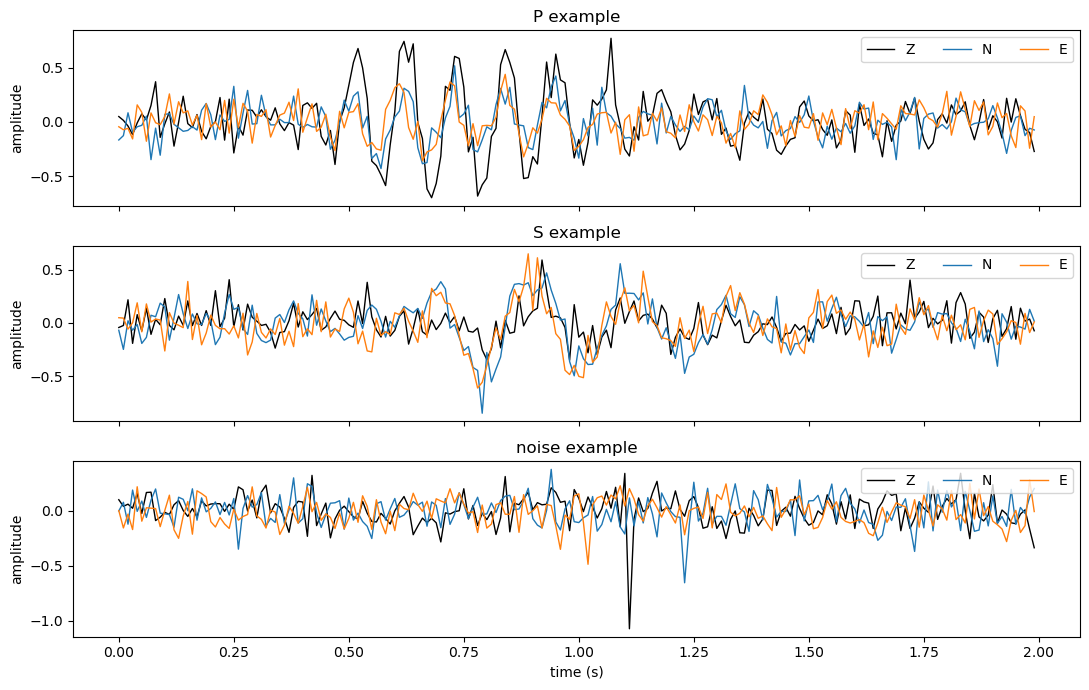

In [3]:
components = {c: [f'{c}_{i:03d}' for i in range(200)] for c in ['z', 'n', 'e']}
time = np.arange(200) / 100.0

fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
for ax, label in zip(axes, ['P', 'S', 'noise']):
    row = df[df.label == label].iloc[0]
    for component, color in zip(['z', 'n', 'e'], ['black', 'tab:blue', 'tab:orange']):
        ax.plot(time, row[components[component]].to_numpy(float), label=component.upper(), color=color, linewidth=1)
    ax.set_title(f'{label} example')
    ax.set_ylabel('amplitude')
    ax.legend(loc='upper right', ncol=3)
axes[-1].set_xlabel('time (s)')
plt.tight_layout()
plt.show()

## 2. PyTorch 데이터셋

훈련 데이터에서 계산한 채널별 평균과 표준편차만 사용하여 모든 분할을 정규화합니다. 시험 데이터 정보가 학습에 새어 들어가는 것을 막기 위함입니다.

In [4]:
LABEL_TO_ID = {'P': 0, 'S': 1, 'noise': 2}
ID_TO_LABEL = {v: k for k, v in LABEL_TO_ID.items()}
feature_columns = components['z'] + components['n'] + components['e']

def frame_to_x(frame):
    return frame[feature_columns].to_numpy(np.float32).reshape(-1, 3, 200)

train_raw = frame_to_x(df[df.split == 'train'])
channel_mean = train_raw.mean(axis=(0, 2), keepdims=True)
channel_std = train_raw.std(axis=(0, 2), keepdims=True) + 1e-6

class SeismicDataset(Dataset):
    def __init__(self, frame):
        x = frame_to_x(frame)
        self.x = torch.tensor((x - channel_mean) / channel_std, dtype=torch.float32)
        self.y = torch.tensor(frame.label.map(LABEL_TO_ID).to_numpy(), dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, index):
        return self.x[index], self.y[index]

train_ds = SeismicDataset(df[df.split == 'train'])
val_ds = SeismicDataset(df[df.split == 'val'])
test_ds = SeismicDataset(df[df.split == 'test'])
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)
print(len(train_ds), len(val_ds), len(test_ds))

141 30 29


## 3. 1D CNN 분류 모델

In [6]:
class SeismicCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(3, 24, 9, padding=4), nn.BatchNorm1d(24), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(24, 48, 7, padding=3), nn.BatchNorm1d(48), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(48, 96, 5, padding=2), nn.BatchNorm1d(96), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(0.2), nn.Linear(96, 3))
    def forward(self, x):
        return self.classifier(self.features(x))

model = SeismicCNN().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
print(model)

SeismicCNN(
  (features): Sequential(
    (0): Conv1d(3, 24, kernel_size=(9,), stride=(1,), padding=(4,))
    (1): BatchNorm1d(24, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(24, 48, kernel_size=(7,), stride=(1,), padding=(3,))
    (5): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(48, 96, kernel_size=(5,), stride=(1,), padding=(2,))
    (9): BatchNorm1d(96, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool1d(output_size=1)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.2, inplace=False)
    (2): Linear(in_features=96, out_features=3, bias=True)
  )
)


## 4. 학습

검증 손실이 가장 낮은 가중치를 메모리에 보관합니다.

In [7]:
def evaluate_loss(loader):
    model.eval()
    total_loss, total_count = 0.0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            loss = criterion(model(x), y)
            total_loss += loss.item() * len(y)
            total_count += len(y)
    return total_loss / total_count

history = {'train': [], 'val': []}
best_val = float('inf')
best_state = None

for epoch in range(25):
    model.train()
    running, count = 0.0, 0
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        running += loss.item() * len(y)
        count += len(y)
    train_loss = running / count
    val_loss = evaluate_loss(val_loader)
    history['train'].append(train_loss)
    history['val'].append(val_loss)
    if val_loss < best_val:
        best_val = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    print(f'epoch {epoch+1:02d} | train {train_loss:.4f} | val {val_loss:.4f}')

model.load_state_dict(best_state)

epoch 01 | train 0.7458 | val 0.7740
epoch 02 | train 0.4006 | val 0.3566
epoch 03 | train 0.2749 | val 0.2106
epoch 04 | train 0.2117 | val 0.1345
epoch 05 | train 0.1588 | val 0.0992
epoch 06 | train 0.1176 | val 0.0831
epoch 07 | train 0.1002 | val 0.0677
epoch 08 | train 0.1032 | val 0.0583
epoch 09 | train 0.0610 | val 0.0651
epoch 10 | train 0.0470 | val 0.0675
epoch 11 | train 0.0603 | val 0.0413
epoch 12 | train 0.0411 | val 0.0277
epoch 13 | train 0.0296 | val 0.0239
epoch 14 | train 0.0388 | val 0.0156
epoch 15 | train 0.0246 | val 0.0133
epoch 16 | train 0.0305 | val 0.0133
epoch 17 | train 0.0210 | val 0.0100
epoch 18 | train 0.0217 | val 0.0085
epoch 19 | train 0.0178 | val 0.0086
epoch 20 | train 0.0196 | val 0.0081
epoch 21 | train 0.0133 | val 0.0058
epoch 22 | train 0.0099 | val 0.0055
epoch 23 | train 0.0108 | val 0.0052
epoch 24 | train 0.0165 | val 0.0061
epoch 25 | train 0.0110 | val 0.0107


<All keys matched successfully>

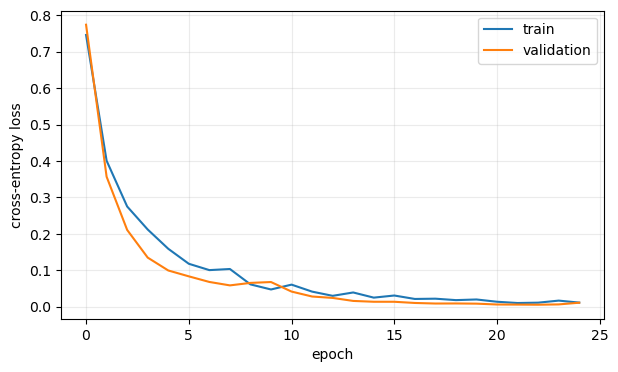

In [9]:
plt.figure(figsize=(7, 4))
plt.plot(history['train'], label='train')
plt.plot(history['val'], label='validation')
plt.xlabel('epoch')
plt.ylabel('cross-entropy loss')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 5. 시험 데이터 평가

              precision    recall  f1-score   support

           P      1.000     1.000     1.000        10
           S      1.000     1.000     1.000        10
       noise      1.000     1.000     1.000         9

    accuracy                          1.000        29
   macro avg      1.000     1.000     1.000        29
weighted avg      1.000     1.000     1.000        29



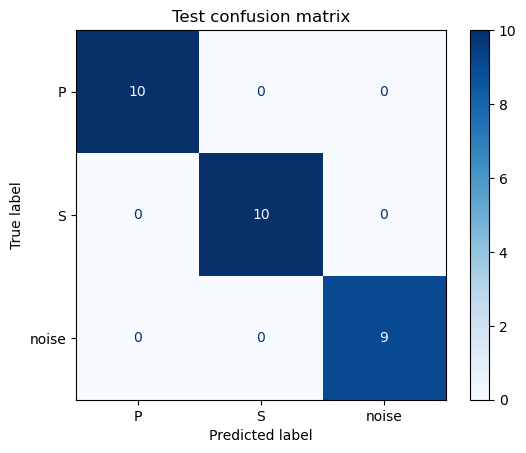

In [10]:
model.eval()
y_true, y_pred, probabilities = [], [], []
with torch.no_grad():
    for x, y in test_loader:
        logits = model(x.to(DEVICE))
        prob = torch.softmax(logits, dim=1).cpu()
        y_true.extend(y.numpy())
        y_pred.extend(prob.argmax(1).numpy())
        probabilities.extend(prob.numpy())

class_names = ['P', 'S', 'noise']
print(classification_report(y_true, y_pred, target_names=class_names, digits=3, zero_division=0))
cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(cmap='Blues')
plt.title('Test confusion matrix')
plt.show()

## 6. 개별 예측 확인

In [11]:
test_frame = df[df.split == 'test'].reset_index(drop=True).copy()
probabilities = np.asarray(probabilities)
test_frame['prediction'] = [ID_TO_LABEL[i] for i in y_pred]
test_frame['confidence'] = probabilities.max(axis=1)
display(test_frame[['sample_id', 'label', 'prediction', 'confidence']].head(15))

,sample_id,label,prediction,confidence
0,syn_058,P,P,0.998810
1,syn_059,P,P,0.999408
2,syn_060,P,P,0.991264
3,syn_061,P,P,0.982308
4,syn_062,P,P,0.997697
5,syn_063,P,P,0.995532
6,syn_064,P,P,0.999439
7,syn_065,P,P,0.966912
8,syn_066,P,P,0.999564
9,syn_067,P,P,0.994611


## 다음 단계

실제 자료로 확장할 때는 합성 CSV 대신 관측 파형을 동일한 `(개수, 3, 길이)` 배열로 변환하면 됩니다. 실제 P/S 도착시각을 찾는 문제는 이 노트북의 **윈도우 단위 분류**와 달리, 각 시점에 `P/S/noise` 확률을 출력하는 PhaseNet 계열 **시계열 분할 모델**이 필요합니다.